--- Iniciando Processamento ---
Vetorizando textos (N-grams e pronomes)...
Balanceando categorias com SMOTE (aguarde)...
Treinando XGBoost Final com 250 árvores...
[0]	validation_0-mlogloss:1.87257
[50]	validation_0-mlogloss:1.01965
[100]	validation_0-mlogloss:0.89138
[150]	validation_0-mlogloss:0.83371
[200]	validation_0-mlogloss:0.80151
[249]	validation_0-mlogloss:0.78255

✅ Treinamento concluído em 25.92 minutos.

=== RELATÓRIO DE CLASSIFICAÇÃO FINAL ===
               precision    recall  f1-score   support

         ADHD       0.89      0.85      0.87       401
      Anxiety       0.75      0.71      0.73       384
       Autism       0.77      0.80      0.79       299
          BPD       0.81      0.81      0.81       324
      Bipolar       0.79      0.72      0.75       365
   Depression       0.57      0.67      0.62       287
schizophrenia       0.57      0.62      0.59       195

     accuracy                           0.75      2255
    macro avg       0.74      0.74      0

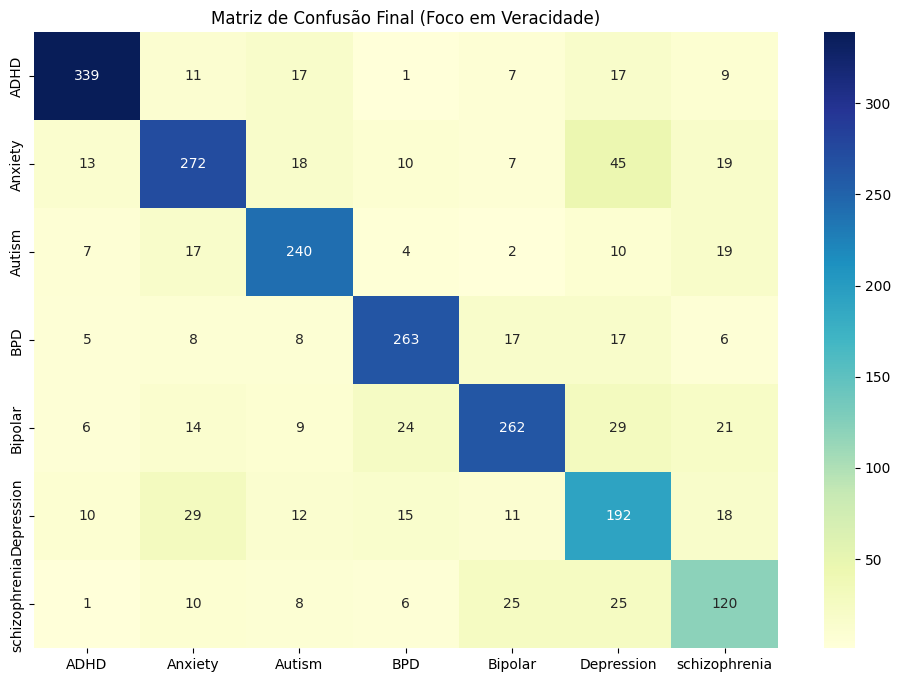

------------------------------
ANÁLISE DE TEXTO COMPLEXO:
Texto: 
I've been struggling for months now. Every time I try to focus on my college papers, 
my mind jumps...
Diagnóstico Provável: ADHD
Nível de Confiança: 47.87%
------------------------------


('ADHD', np.float32(0.4787464))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# 1. Carga e Limpeza
print("--- Iniciando Processamento ---")
df_text = pd.read_csv('../data/Mental Health Disorder Detection Dataset.csv')
df_text = df_text.dropna(subset=['body', 'category'])

# 2. Preparação do Alvo
le_nlp = LabelEncoder()
y = le_nlp.fit_transform(df_text['category'])
target_names = le_nlp.classes_

# 3. Divisão Estratificada
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    df_text['body'], y, test_size=0.2, random_state=42, stratify=y
)

# 4. TF-IDF Otimizado
print("Vetorizando textos (N-grams e pronomes)...")
vectorizer = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2),
    min_df=5
)
X_train_vec = vectorizer.fit_transform(X_train_t)
X_test_vec = vectorizer.transform(X_test_t)

# 5. Balanceamento (SMOTE)
print("Balanceando categorias com SMOTE (aguarde)...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train_t)

# 6. Modelo XGBoost com Monitoramento de Progresso
print(f"Treinando XGBoost Final com 250 árvores...")
start_time = time.time()

modelo_nlp_final = XGBClassifier(
    n_estimators=250, 
    learning_rate=0.05, 
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=1 # Mostra o log no console
)

# Para acompanhar o progresso, usamos o eval_set
modelo_nlp_final.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_vec, y_test_t)],
    verbose=50 # Imprime o progresso a cada 50 iterações (0, 50, 100...)
)

end_time = time.time()
print(f"\n✅ Treinamento concluído em {(end_time - start_time)/60:.2f} minutos.")

# 7. Relatório Final
y_pred_t = modelo_nlp_final.predict(X_test_vec)
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO FINAL ===")
print(classification_report(y_test_t, y_pred_t, target_names=target_names))

# 8. Salvando Arquivos
joblib.dump(modelo_nlp_final, '../src/modelo_nlp_final.pkl')
joblib.dump(vectorizer, '../src/vectorizer_nlp.pkl')
joblib.dump(le_nlp, '../src/label_encoder_nlp.pkl')

# 9. Matriz de Confusão
plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test_t, y_pred_t), annot=True, fmt='d', 
            xticklabels=target_names, yticklabels=target_names, cmap='YlGnBu')
plt.title('Matriz de Confusão Final (Foco em Veracidade)')
plt.show()

# 10. Teste de Stress (Frase Complexa e Longa)
def prever_texto_clinico(texto):
    vec = vectorizer.transform([texto])
    pred = modelo_nlp_final.predict(vec)[0]
    probs = modelo_nlp_final.predict_proba(vec)[0]
    doenca = le_nlp.inverse_transform([pred])[0]
    certeza = probs[pred]
    
    print("-" * 30)
    print(f"ANÁLISE DE TEXTO COMPLEXO:")
    print(f"Texto: {texto[:100]}...") 
    print(f"Diagnóstico Provável: {doenca}")
    print(f"Nível de Confiança: {certeza*100:.2f}%")
    print("-" * 30)
    return doenca, certeza

# Exemplo de frase mais complexa para o seu TCC
frase_complexa = """
I've been struggling for months now. Every time I try to focus on my college papers, 
my mind jumps to a thousand different places and I feel this crushing weight in my chest. 
I can't sleep because I'm constantly replaying every conversation I had during the day, 
wondering if I said something wrong. Sometimes I feel so energetic I could clean the 
whole house at 3 AM, but then I crash and can't even get out of bed for two days.
"""

prever_texto_clinico(frase_complexa)